<div style="
    background: linear-gradient(135deg, #fff4e6, #eef6ff);
    border-left: 8px solid #ff8c42;
    padding: 28px;
    border-radius: 14px;
    text-align: center;
">

# 🛒 Market Basket Analysis using Apriori Algorithm

### Module 6 — Association Rule Mining

**Prepared by:** lovisha Jaat 
</div>

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

ModuleNotFoundError: No module named 'mlxtend'

In [3]:
transactions = [
    ["Milk", "Bread", "Butter"],
    ["Bread", "Eggs", "Milk"],
    ["Milk", "Bread", "Diapers", "Beer"],
    ["Bread", "Butter", "Jam"],
    ["Milk", "Eggs", "Bread"],
    ["Diapers", "Beer", "Chips"],
    ["Milk", "Bread", "Butter", "Eggs"],
    ["Bread", "Tea", "Sugar"],
    ["Milk", "Bread", "Diapers", "Beer"],
    ["Bread", "Butter", "Cheese"],
    ["Milk", "Eggs", "Bread", "Butter"],
    ["Tea", "Sugar", "Biscuits"],
    ["Milk", "Bread", "Cheese"],
    ["Bread", "Jam", "Butter"],
    ["Diapers", "Beer", "Milk"],
    ["Milk", "Bread", "Eggs"],
    ["Bread", "Butter", "Tea"],
    ["Milk", "Bread", "Diapers"],
    ["Chips", "Soft Drink", "Biscuits"],
    ["Bread", "Eggs", "Butter"],
    ["Milk", "Bread", "Butter"],
    ["Tea", "Sugar", "Bread"],
    ["Milk", "Cheese", "Bread"],
    ["Diapers", "Beer", "Chips"],
    ["Bread", "Butter", "Jam"],
    ["Milk", "Eggs", "Bread"],
    ["Bread", "Biscuits", "Tea"],
    ["Milk", "Bread", "Diapers", "Beer"],
    ["Bread", "Butter", "Cheese"],
    ["Milk", "Bread", "Eggs", "Butter"]
]

print("Total Transactions:", len(transactions))

transactions[:5]

Total Transactions: 30


[['Milk', 'Bread', 'Butter'],
 ['Bread', 'Eggs', 'Milk'],
 ['Milk', 'Bread', 'Diapers', 'Beer'],
 ['Bread', 'Butter', 'Jam'],
 ['Milk', 'Eggs', 'Bread']]

In [3]:
transaction_df = pd.DataFrame({
    "Transaction_ID": range(1, len(transactions) + 1),
    "Items": [", ".join(items) for items in transactions]
})

transaction_df.head(10)

,Transaction_ID,Items
0,1,"Milk, Bread, Butter"
1,2,"Bread, Eggs, Milk"
2,3,"Milk, Bread, Diapers, Beer"
3,4,"Bread, Butter, Jam"
4,5,"Milk, Eggs, Bread"
5,6,"Diapers, Beer, Chips"
6,7,"Milk, Bread, Butter, Eggs"
7,8,"Bread, Tea, Sugar"
8,9,"Milk, Bread, Diapers, Beer"
9,10,"Bread, Butter, Cheese"


In [4]:
print("Dataset Shape:", transaction_df.shape)

print("\nMissing Values:")
print(transaction_df.isnull().sum())

print("\nData Types:")
print(transaction_df.dtypes)

print("\nFirst Five Transactions:")
display(transaction_df.head())

Dataset Shape: (30, 2)

Missing Values:
Transaction_ID    0
Items             0
dtype: int64

Data Types:
Transaction_ID    int64
Items               str
dtype: object

First Five Transactions:


,Transaction_ID,Items
0,1,"Milk, Bread, Butter"
1,2,"Bread, Eggs, Milk"
2,3,"Milk, Bread, Diapers, Beer"
3,4,"Bread, Butter, Jam"
4,5,"Milk, Eggs, Bread"


In [5]:
all_items = [
    item
    for transaction in transactions
    for item in transaction
]

item_frequency = pd.Series(all_items).value_counts()

item_frequency

Bread         25
Milk          16
Butter        12
Eggs           8
Diapers        7
Beer           6
Tea            5
Cheese         4
Jam            3
Chips          3
Sugar          3
Biscuits       3
Soft Drink     1
Name: count, dtype: int64

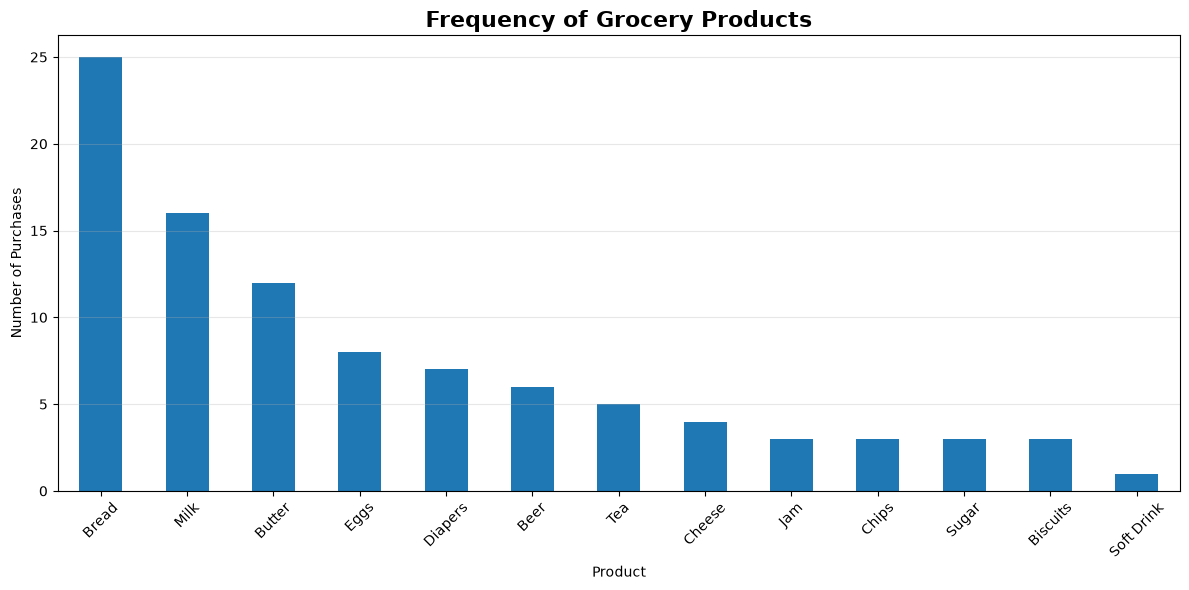

In [6]:
plt.figure(figsize=(12, 6))

item_frequency.plot(kind="bar")

plt.title(
    "Frequency of Grocery Products",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
encoder = TransactionEncoder()

encoded_array = encoder.fit(
    transactions
).transform(transactions)

basket_df = pd.DataFrame(
    encoded_array,
    columns=encoder.columns_
)

basket_df.head()

,Beer,Biscuits,Bread,Butter,Cheese,Chips,Diapers,Eggs,Jam,Milk,Soft Drink,Sugar,Tea
0,False,False,True,True,False,False,False,False,False,True,False,False,False
1,False,False,True,False,False,False,False,True,False,True,False,False,False
2,True,False,True,False,False,False,True,False,False,True,False,False,False
3,False,False,True,True,False,False,False,False,True,False,False,False,False
4,False,False,True,False,False,False,False,True,False,True,False,False,False


In [8]:
print("Encoded Dataset Shape:", basket_df.shape)

print("\nEncoded Columns:")
print(basket_df.columns.tolist())

basket_df.head(10)

Encoded Dataset Shape: (30, 13)

Encoded Columns:
['Beer', 'Biscuits', 'Bread', 'Butter', 'Cheese', 'Chips', 'Diapers', 'Eggs', 'Jam', 'Milk', 'Soft Drink', 'Sugar', 'Tea']


,Beer,Biscuits,Bread,Butter,Cheese,Chips,Diapers,Eggs,Jam,Milk,Soft Drink,Sugar,Tea
0,False,False,True,True,False,False,False,False,False,True,False,False,False
1,False,False,True,False,False,False,False,True,False,True,False,False,False
2,True,False,True,False,False,False,True,False,False,True,False,False,False
3,False,False,True,True,False,False,False,False,True,False,False,False,False
4,False,False,True,False,False,False,False,True,False,True,False,False,False
5,True,False,False,False,False,True,True,False,False,False,False,False,False
6,False,False,True,True,False,False,False,True,False,True,False,False,False
7,False,False,True,False,False,False,False,False,False,False,False,True,True
8,True,False,True,False,False,False,True,False,False,True,False,False,False
9,False,False,True,True,True,False,False,False,False,False,False,False,False


In [9]:
frequent_itemsets = apriori(
    basket_df,
    min_support=0.20,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets

,support,itemsets
0,0.833333,frozenset({Bread})
1,0.533333,frozenset({Milk})
2,0.500000,"frozenset({Bread, Milk})"
3,0.400000,frozenset({Butter})
4,0.400000,"frozenset({Bread, Butter})"
5,0.266667,frozenset({Eggs})
6,0.266667,"frozenset({Bread, Eggs})"
7,0.233333,frozenset({Diapers})
8,0.233333,"frozenset({Eggs, Bread, Milk})"
9,0.233333,"frozenset({Eggs, Milk})"


In [12]:
# Create itemset length column
frequent_itemsets["Itemset_Length"] = (
    frequent_itemsets["itemsets"].apply(len)
)

# Filter single-item frequent itemsets
single_itemsets = frequent_itemsets[
    frequent_itemsets["Itemset_Length"] == 1
]

single_itemsets

,support,itemsets,Itemset_Length
0,0.833333,frozenset({Bread}),1
1,0.533333,frozenset({Milk}),1
3,0.400000,frozenset({Butter}),1
5,0.266667,frozenset({Eggs}),1
7,0.233333,frozenset({Diapers}),1
10,0.200000,frozenset({Beer}),1


In [13]:
pair_itemsets = frequent_itemsets[
    frequent_itemsets["Itemset_Length"] == 2
]

pair_itemsets

,support,itemsets,Itemset_Length
2,0.500000,"frozenset({Bread, Milk})",2
4,0.400000,"frozenset({Bread, Butter})",2
6,0.266667,"frozenset({Bread, Eggs})",2
9,0.233333,"frozenset({Eggs, Milk})",2
11,0.200000,"frozenset({Beer, Diapers})",2


In [14]:
triple_itemsets = frequent_itemsets[
    frequent_itemsets["Itemset_Length"] == 3
]

triple_itemsets

,support,itemsets,Itemset_Length
8,0.233333,"frozenset({Eggs, Bread, Milk})",3


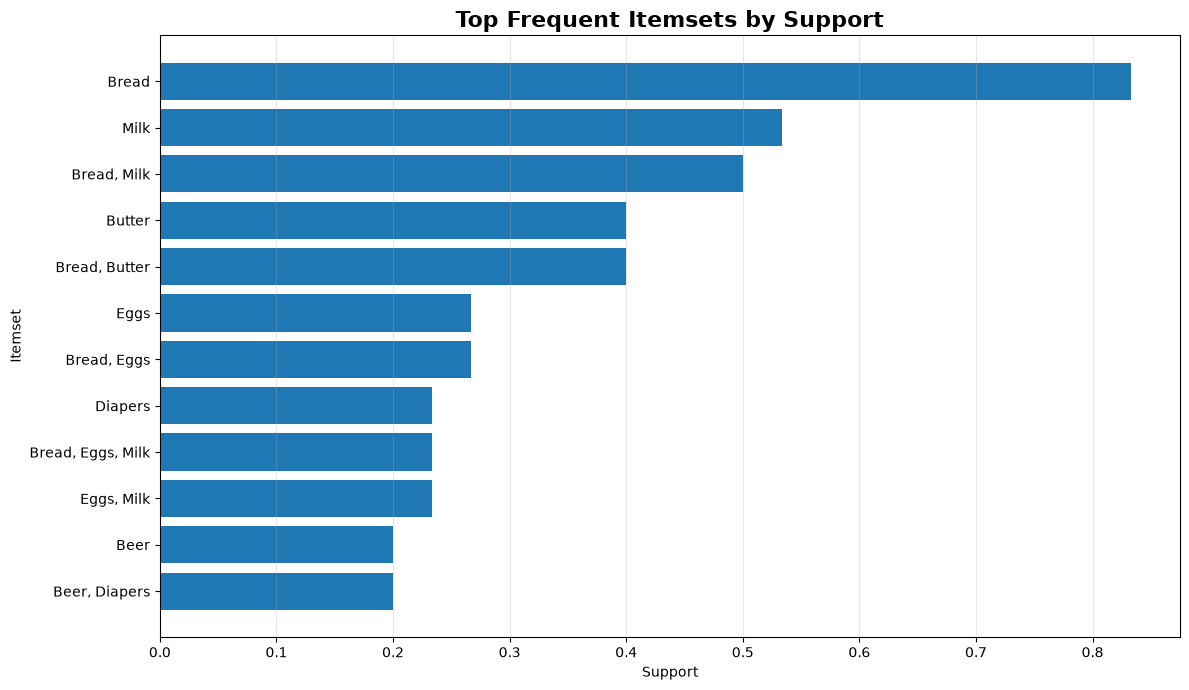

In [15]:
top_itemsets = frequent_itemsets.head(15).copy()

top_itemsets["Itemset"] = top_itemsets[
    "itemsets"
].apply(lambda x: ", ".join(sorted(list(x))))

plt.figure(figsize=(12, 7))

plt.barh(
    top_itemsets["Itemset"],
    top_itemsets["support"]
)

plt.title(
    "Top Frequent Itemsets by Support",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Support")
plt.ylabel("Itemset")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Bread}),frozenset({Milk}),0.833333,0.533333,0.500000,0.6000,1.125000,1.0,0.055556,1.166667,0.666667,0.576923,0.142857,0.76875
1,frozenset({Milk}),frozenset({Bread}),0.533333,0.833333,0.500000,0.9375,1.125000,1.0,0.055556,2.666667,0.238095,0.576923,0.625000,0.76875
2,frozenset({Butter}),frozenset({Bread}),0.400000,0.833333,0.400000,1.0000,1.200000,1.0,0.066667,inf,0.277778,0.480000,1.000000,0.74000
3,frozenset({Eggs}),frozenset({Bread}),0.266667,0.833333,0.266667,1.0000,1.200000,1.0,0.044444,inf,0.227273,0.320000,1.000000,0.66000
4,"frozenset({Bread, Eggs})",frozenset({Milk}),0.266667,0.533333,0.233333,0.8750,1.640625,1.0,0.091111,3.733333,0.532468,0.411765,0.732143,0.65625


In [17]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules = rules.sort_values(
    by="lift",
    ascending=False
).reset_index(drop=True)

rules.head(15)

,antecedents,consequents,support,confidence,lift
0,frozenset({Diapers}),frozenset({Beer}),0.200000,0.857143,4.285714
1,frozenset({Beer}),frozenset({Diapers}),0.200000,1.000000,4.285714
2,frozenset({Eggs}),"frozenset({Bread, Milk})",0.233333,0.875000,1.750000
3,"frozenset({Bread, Eggs})",frozenset({Milk}),0.233333,0.875000,1.640625
4,frozenset({Eggs}),frozenset({Milk}),0.233333,0.875000,1.640625
5,"frozenset({Eggs, Milk})",frozenset({Bread}),0.233333,1.000000,1.200000
6,frozenset({Butter}),frozenset({Bread}),0.400000,1.000000,1.200000
7,frozenset({Eggs}),frozenset({Bread}),0.266667,1.000000,1.200000
8,frozenset({Milk}),frozenset({Bread}),0.500000,0.937500,1.125000
9,frozenset({Bread}),frozenset({Milk}),0.500000,0.600000,1.125000


In [18]:
rules["antecedents"] = rules[
    "antecedents"
].apply(lambda x: ", ".join(sorted(list(x))))

rules["consequents"] = rules[
    "consequents"
].apply(lambda x: ", ".join(sorted(list(x))))

rules.head(15)

,antecedents,consequents,support,confidence,lift
0,Diapers,Beer,0.200000,0.857143,4.285714
1,Beer,Diapers,0.200000,1.000000,4.285714
2,Eggs,"Bread, Milk",0.233333,0.875000,1.750000
3,"Bread, Eggs",Milk,0.233333,0.875000,1.640625
4,Eggs,Milk,0.233333,0.875000,1.640625
5,"Eggs, Milk",Bread,0.233333,1.000000,1.200000
6,Butter,Bread,0.400000,1.000000,1.200000
7,Eggs,Bread,0.266667,1.000000,1.200000
8,Milk,Bread,0.500000,0.937500,1.125000
9,Bread,Milk,0.500000,0.600000,1.125000


In [19]:
rules["support"] = rules["support"].round(3)
rules["confidence"] = rules["confidence"].round(3)
rules["lift"] = rules["lift"].round(3)

rules.head(15)

,antecedents,consequents,support,confidence,lift
0,Diapers,Beer,0.200,0.857,4.286
1,Beer,Diapers,0.200,1.000,4.286
2,Eggs,"Bread, Milk",0.233,0.875,1.750
3,"Bread, Eggs",Milk,0.233,0.875,1.641
4,Eggs,Milk,0.233,0.875,1.641
5,"Eggs, Milk",Bread,0.233,1.000,1.200
6,Butter,Bread,0.400,1.000,1.200
7,Eggs,Bread,0.267,1.000,1.200
8,Milk,Bread,0.500,0.938,1.125
9,Bread,Milk,0.500,0.600,1.125


In [20]:
strong_rules = rules[
    (rules["confidence"] >= 0.60) &
    (rules["lift"] > 1.0)
].copy()

strong_rules = strong_rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

strong_rules

,antecedents,consequents,support,confidence,lift
0,Beer,Diapers,0.200,1.000,4.286
1,Diapers,Beer,0.200,0.857,4.286
2,Eggs,"Bread, Milk",0.233,0.875,1.750
3,"Bread, Eggs",Milk,0.233,0.875,1.641
4,Eggs,Milk,0.233,0.875,1.641
5,"Eggs, Milk",Bread,0.233,1.000,1.200
6,Butter,Bread,0.400,1.000,1.200
7,Eggs,Bread,0.267,1.000,1.200
8,Milk,Bread,0.500,0.938,1.125
9,Bread,Milk,0.500,0.600,1.125


In [21]:
print("Total Frequent Itemsets:", len(frequent_itemsets))
print("Total Association Rules:", len(rules))
print("Strong Association Rules:", len(strong_rules))

Total Frequent Itemsets: 12
Total Association Rules: 10
Strong Association Rules: 10


In [22]:
top_confidence_rules = rules.sort_values(
    by="confidence",
    ascending=False
).head(10)

top_confidence_rules

,antecedents,consequents,support,confidence,lift
1,Beer,Diapers,0.200,1.000,4.286
5,"Eggs, Milk",Bread,0.233,1.000,1.200
7,Eggs,Bread,0.267,1.000,1.200
6,Butter,Bread,0.400,1.000,1.200
8,Milk,Bread,0.500,0.938,1.125
4,Eggs,Milk,0.233,0.875,1.641
2,Eggs,"Bread, Milk",0.233,0.875,1.750
3,"Bread, Eggs",Milk,0.233,0.875,1.641
0,Diapers,Beer,0.200,0.857,4.286
9,Bread,Milk,0.500,0.600,1.125


In [23]:
top_lift_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

top_lift_rules

,antecedents,consequents,support,confidence,lift
0,Diapers,Beer,0.200,0.857,4.286
1,Beer,Diapers,0.200,1.000,4.286
2,Eggs,"Bread, Milk",0.233,0.875,1.750
3,"Bread, Eggs",Milk,0.233,0.875,1.641
4,Eggs,Milk,0.233,0.875,1.641
5,"Eggs, Milk",Bread,0.233,1.000,1.200
6,Butter,Bread,0.400,1.000,1.200
7,Eggs,Bread,0.267,1.000,1.200
8,Milk,Bread,0.500,0.938,1.125
9,Bread,Milk,0.500,0.600,1.125


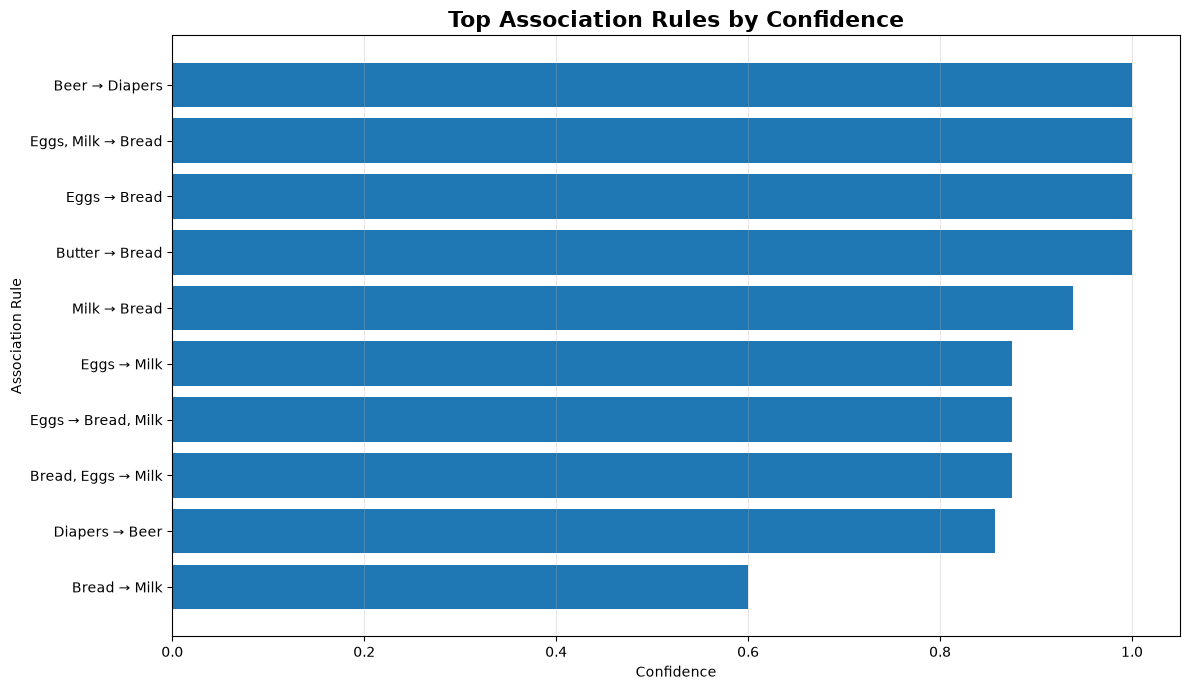

In [24]:
confidence_plot = top_confidence_rules.copy()

confidence_plot["Rule"] = (
    confidence_plot["antecedents"]
    + " → "
    + confidence_plot["consequents"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    confidence_plot["Rule"],
    confidence_plot["confidence"]
)

plt.title(
    "Top Association Rules by Confidence",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

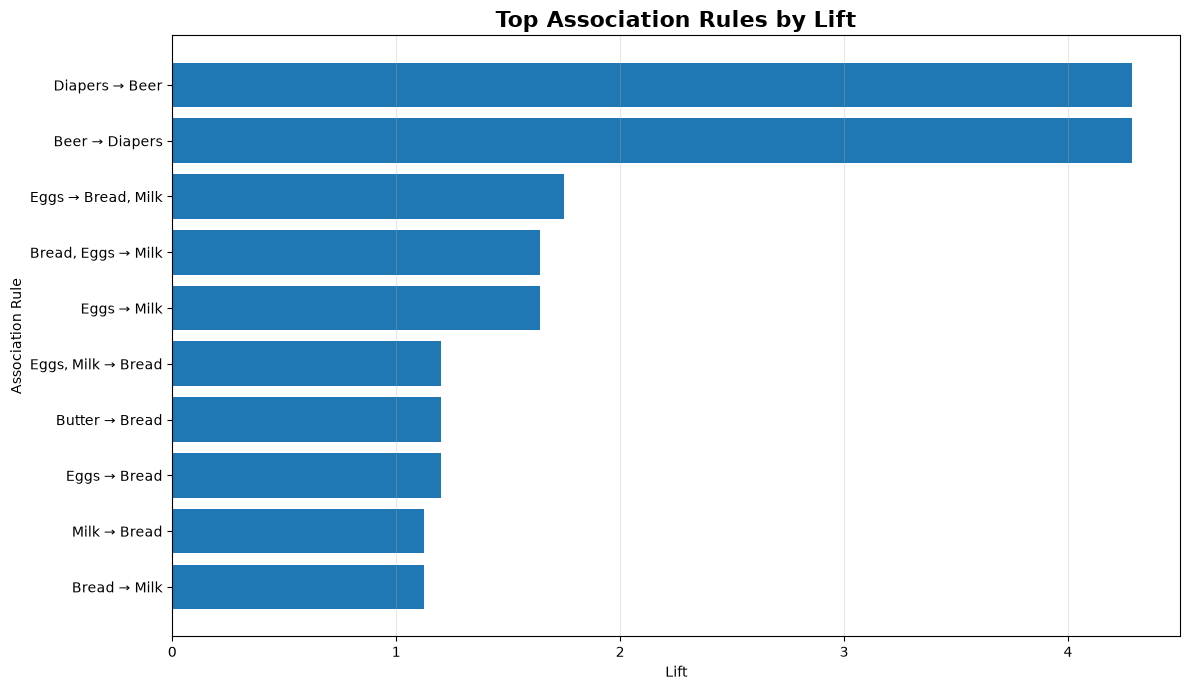

In [25]:
lift_plot = top_lift_rules.copy()

lift_plot["Rule"] = (
    lift_plot["antecedents"]
    + " → "
    + lift_plot["consequents"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    lift_plot["Rule"],
    lift_plot["lift"]
)

plt.title(
    "Top Association Rules by Lift",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

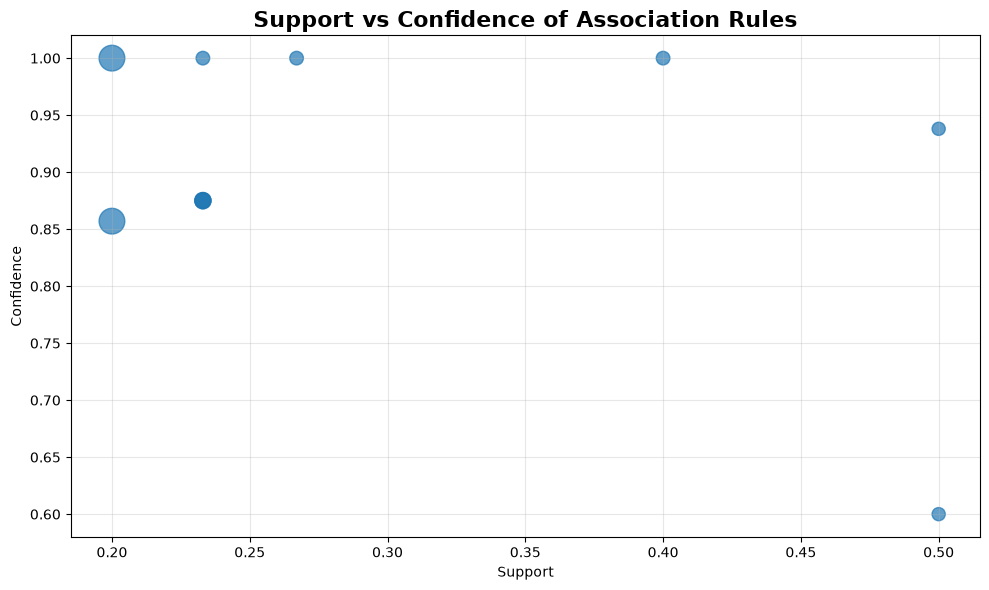

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"] * 80,
    alpha=0.7
)

plt.title(
    "Support vs Confidence of Association Rules",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
if not strong_rules.empty:

    best_rule = strong_rules.iloc[0]

    print("Best Association Rule")
    print("-" * 40)

    print("If Customer Buys:")
    print(best_rule["antecedents"])

    print("\nCustomer May Also Buy:")
    print(best_rule["consequents"])

    print("\nSupport:", best_rule["support"])
    print("Confidence:", best_rule["confidence"])
    print("Lift:", best_rule["lift"])

else:
    print("No strong rule found with the selected thresholds.")

Best Association Rule
----------------------------------------
If Customer Buys:
Beer

Customer May Also Buy:
Diapers

Support: 0.2
Confidence: 1.0
Lift: 4.286


In [28]:
for index, row in strong_rules.head(10).iterrows():

    print(
        f"Rule {index + 1}: "
        f"If a customer buys [{row['antecedents']}], "
        f"they may also buy [{row['consequents']}]"
    )

    print(
        f"Support: {row['support']}, "
        f"Confidence: {row['confidence']}, "
        f"Lift: {row['lift']}"
    )

    print("-" * 70)

Rule 1: If a customer buys [Beer], they may also buy [Diapers]
Support: 0.2, Confidence: 1.0, Lift: 4.286
----------------------------------------------------------------------
Rule 2: If a customer buys [Diapers], they may also buy [Beer]
Support: 0.2, Confidence: 0.857, Lift: 4.286
----------------------------------------------------------------------
Rule 3: If a customer buys [Eggs], they may also buy [Bread, Milk]
Support: 0.233, Confidence: 0.875, Lift: 1.75
----------------------------------------------------------------------
Rule 4: If a customer buys [Bread, Eggs], they may also buy [Milk]
Support: 0.233, Confidence: 0.875, Lift: 1.641
----------------------------------------------------------------------
Rule 5: If a customer buys [Eggs], they may also buy [Milk]
Support: 0.233, Confidence: 0.875, Lift: 1.641
----------------------------------------------------------------------
Rule 6: If a customer buys [Eggs, Milk], they may also buy [Bread]
Support: 0.233, Confidence: 1.

In [29]:
frequent_itemsets_export = frequent_itemsets.copy()

frequent_itemsets_export["itemsets"] = (
    frequent_itemsets_export["itemsets"]
    .apply(lambda x: ", ".join(sorted(list(x))))
)

frequent_itemsets_export.to_csv(
    "apriori_frequent_itemsets.csv",
    index=False
)

rules.to_csv(
    "apriori_association_rules.csv",
    index=False
)

print("Files saved successfully:")
print("1. apriori_frequent_itemsets.csv")
print("2. apriori_association_rules.csv")

Files saved successfully:
1. apriori_frequent_itemsets.csv
2. apriori_association_rules.csv


<div style="
    background: linear-gradient(135deg, #edfff3, #eef4ff);
    border-left: 8px solid #2e9d62;
    padding: 25px;
    border-radius: 14px;
">

## ✅ Conclusion

In this notebook, we successfully implemented the **Apriori Algorithm** using a Grocery Store Transactions Dataset.

The algorithm was used to:

- Convert grocery transactions into basket format
- Identify frequently purchased products
- Generate frequent itemsets
- Generate association rules
- Evaluate rules using support, confidence and lift
- Filter strong product relationships
- Visualize product frequencies and association-rule performance

### Evaluation interpretation

- **Support** indicates how frequently an itemset appears in all transactions.
- **Confidence** indicates how often the consequent is purchased when the antecedent is purchased.
- **Lift** measures the strength of the relationship between two itemsets.

A lift value greater than `1` indicates a positive association between products.

The generated rules can help grocery stores improve product placement, combo offers, recommendations, cross-selling strategies and promotional campaigns.

</div>